# Phase 2: Full Slate Prediction

Scale Phase 1 pipeline to all players on a single slate

Steps:
1. Load slate data and historical logs
2. Filter players with sufficient training data
3. Train per-player models
4. Generate predictions for all players
5. Analyze results by salary tiers and positions
6. Visualize performance with cross-analysis
7. Identify position-specific patterns

## 1. Configuration

In [85]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

from src.data.loaders.historical_loader import HistoricalDataLoader
from src.utils.feature_config import load_feature_config
from src.features.pipeline import FeaturePipeline
from xgboost import XGBRegressor

# Test slate configuration
TEST_DATE = '20250205'
NUM_SEASONS = 2
FEATURE_CONFIG = 'base_features'
TARGET = 'fantasyPoints'
DATA_DIR = '../data'
MIN_GAMES = 10  # Minimum games in training window

# Model configuration
MODEL_CONFIG = {
    'max_depth': 6,
    'learning_rate': 0.05,
    'n_estimators': 100,
    'min_child_weight': 3,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'objective': 'reg:squarederror',
    'random_state': 42,
    'tree_method': 'hist'
}

print(f"Test date: {TEST_DATE}")
print(f"Training seasons: {NUM_SEASONS}")
print(f"Feature config: {FEATURE_CONFIG}")
print(f"Target: {TARGET}")
print(f"Min training games: {MIN_GAMES}")

Test date: 20250205
Training seasons: 2
Feature config: base_features
Target: fantasyPoints
Min training games: 10


In [86]:
def calculate_dk_fantasy_points(stats: pd.Series) -> float:
    """
    Calculate DraftKings fantasy points from box score stats.

    Scoring:
    - Points: 1.0
    - 3PT Made: 0.5 bonus
    - Rebounds: 1.25
    - Assists: 1.5
    - Steals: 2.0
    - Blocks: 2.0
    - Turnovers: -0.5
    - Double-double: +1.5
    - Triple-double: +3.0 (includes double-double bonus)

    Args:
        stats: Series containing player stats (pts, reb, ast, stl, blk, TOV, tptfgm)

    Returns:
        Fantasy points as float
    """
    pts = float(stats.get('pts', 0) or 0)
    tptfgm = float(stats.get('tptfgm', 0) or 0)
    reb = float(stats.get('reb', 0) or 0)
    ast = float(stats.get('ast', 0) or 0)
    stl = float(stats.get('stl', 0) or 0)
    blk = float(stats.get('blk', 0) or 0)
    tov = float(stats.get('TOV', 0) or 0)

    fpts = (
        pts * 1.0 +
        tptfgm * 0.5 +
        reb * 1.25 +
        ast * 1.5 +
        stl * 2.0 +
        blk * 2.0 -
        tov * 0.5
    )

    double_double = sum([pts >= 10, reb >= 10, ast >= 10, stl >= 10, blk >= 10]) >= 2
    if double_double:
        fpts += 1.5

    triple_double = sum([pts >= 10, reb >= 10, ast >= 10, stl >= 10, blk >= 10]) >= 3
    if triple_double:
        fpts += 1.5

    return round(fpts, 2)

print("Fantasy points calculation function loaded")

Fantasy points calculation function loaded


## 2. Load Test Slate Data

In [87]:
loader = HistoricalDataLoader(data_dir=DATA_DIR)

# Load slate data
test_slate = loader.load_slate_data(TEST_DATE)
schedule = test_slate['games']

print(f"Games on {TEST_DATE}: {len(schedule)}")

# Get teams playing
teams_playing = set()
if 'away' in schedule.columns and 'home' in schedule.columns:
    teams_playing.update(schedule['away'].unique())
    teams_playing.update(schedule['home'].unique())

print(f"Teams playing: {len(teams_playing)}")

# Load player logs for test date
player_logs_all = loader.load_historical_data(
    start_date=TEST_DATE,
    end_date=TEST_DATE,
    data_types=['player_logs_extracted']
)['player_logs_extracted']

player_logs = player_logs_all[player_logs_all['team'].isin(teams_playing)].copy()

# Calculate fantasy points
player_logs = player_logs.drop(columns=['fantasyPoints', 'fantasyPts'], errors='ignore')
player_logs['fantasyPoints'] = player_logs.apply(calculate_dk_fantasy_points, axis=1)

print(f"Player logs: {len(player_logs)}")

# Merge with salaries
salaries = test_slate['dfs_salaries']
test_slate_combined = player_logs.merge(
    salaries[['playerID', 'salary', 'pos', 'allValidPositions']],
    on='playerID',
    how='inner'
)

print(f"Players with logs and salaries: {len(test_slate_combined)}")

Games on 20250205: 11
Teams playing: 22


Player logs: 248
Players with logs and salaries: 248


In [88]:
loader = HistoricalDataLoader(data_dir=DATA_DIR)

# Load slate data
test_slate = loader.load_slate_data(TEST_DATE)
schedule = test_slate['games']

print(f"Games on {TEST_DATE}: {len(schedule)}")

# Get teams playing
teams_playing = set()
if 'away' in schedule.columns and 'home' in schedule.columns:
    teams_playing.update(schedule['away'].unique())
    teams_playing.update(schedule['home'].unique())

print(f"Teams playing: {len(teams_playing)}")

# Load player logs for test date
player_logs_all = loader.load_historical_data(
    start_date=TEST_DATE,
    end_date=TEST_DATE,
    data_types=['player_logs_extracted']
)['player_logs_extracted']

player_logs = player_logs_all[player_logs_all['team'].isin(teams_playing)].copy()

# Calculate fantasy points
player_logs = player_logs.drop(columns=['fantasyPoints', 'fantasyPts'], errors='ignore')
player_logs['fantasyPoints'] = player_logs.apply(calculate_dk_fantasy_points, axis=1)

print(f"Player logs: {len(player_logs)}")

# Merge with salaries - check what columns exist
salaries = test_slate['dfs_salaries']
print(f"\nDFS Salaries columns: {salaries.columns.tolist()}")

# Merge with all available columns
test_slate_combined = player_logs.merge(
    salaries,  # Merge all columns
    on='playerID',
    how='inner',
    suffixes=('', '_dfs')
)

print(f"\nTest slate combined columns: {test_slate_combined.columns.tolist()}")
print(f"Players with logs and salaries: {len(test_slate_combined)}")

Games on 20250205: 11
Teams playing: 22


Player logs: 248

DFS Salaries columns: ['allValidPositions', 'longName', 'playerID', 'pos', 'salary', 'team', 'teamID', 'gameDate', 'playerName']

Test slate combined columns: ['playerID', 'longName', 'team', 'teamAbv', 'teamID', 'gameID', 'gameDate', 'pos', 'mins', 'pts', 'reb', 'ast', 'stl', 'blk', 'TOV', 'PF', 'fga', 'fgm', 'fgp', 'fta', 'ftm', 'ftp', 'tptfga', 'tptfgm', 'tptfgp', 'OffReb', 'DefReb', 'plusMinus', 'usage', 'tech', 'created_at', 'fantasyPoints', 'allValidPositions', 'longName_dfs', 'pos_dfs', 'salary', 'team_dfs', 'teamID_dfs', 'gameDate_dfs', 'playerName']
Players with logs and salaries: 248


In [89]:
# Get all player IDs from test slate
player_ids = test_slate_combined['playerID'].unique().tolist()

print(f"Loading historical data for {len(player_ids)} players...")

# Load historical logs for all players
historical_logs = loader.load_historical_player_logs(
    end_date=TEST_DATE,
    num_seasons=NUM_SEASONS,
    player_ids=player_ids
)

# Calculate fantasy points
historical_logs = historical_logs.drop(columns=['fantasyPoints', 'fantasyPts'], errors='ignore')
historical_logs['fantasyPoints'] = historical_logs.apply(calculate_dk_fantasy_points, axis=1)

print(f"Historical logs shape: {historical_logs.shape}")
print(f"Date range: {historical_logs['gameDate'].min()} to {historical_logs['gameDate'].max()}")

# Verify no temporal leakage
max_training_date = str(historical_logs['gameDate'].max())[:10].replace('-', '')
assert max_training_date < TEST_DATE, f"Temporal leakage: {max_training_date} >= {TEST_DATE}"
print(f"[OK] No temporal leakage: {max_training_date} < {TEST_DATE}")

Loading historical data for 248 players...
Historical logs shape: (19944, 32)
Date range: 2023-10-24 00:00:00 to 2025-02-04 00:00:00
[OK] No temporal leakage: 20250204 < 20250205


## 4. Filter Players by Minimum Games

In [90]:
# Count games per player in historical data
player_game_counts = historical_logs.groupby('playerID').size()

# Filter players with sufficient data
eligible_players = player_game_counts[player_game_counts >= MIN_GAMES].index.tolist()

# Filter test slate to eligible players
test_slate_filtered = test_slate_combined[test_slate_combined['playerID'].isin(eligible_players)].copy()

print(f"Players with {MIN_GAMES}+ games: {len(eligible_players)}")
print(f"Players filtered out: {len(test_slate_combined) - len(test_slate_filtered)}")
print(f"Coverage: {len(test_slate_filtered) / len(test_slate_combined) * 100:.1f}%")

# Show some filtered players
filtered_out = test_slate_combined[~test_slate_combined['playerID'].isin(eligible_players)]
if len(filtered_out) > 0:
    print(f"\nSample filtered players (< {MIN_GAMES} games):")
    print(filtered_out[['longName', 'team', 'salary', 'fantasyPoints']].tail(10).to_string(index=False))

Players with 10+ games: 241
Players filtered out: 7
Coverage: 97.2%

Sample filtered players (< 10 games):
        longName team  salary  fantasyPoints
     Mason Jones  SAC    3000          10.75
    Jackson Rowe   GS    3000          15.25
    Jaylen Clark  MIN    3300           8.25
   Jalen Bridges  PHO    3000           2.50
 Isaiah Crawford  SAC    3000           2.25
   Spencer Jones  DEN    3000           3.50
Keion Brooks Jr.   NO    3000           0.00


## 5. Setup Feature Pipeline

In [91]:
# Load feature configuration
feature_config = load_feature_config(FEATURE_CONFIG)
pipeline = feature_config.build_pipeline(FeaturePipeline)

print(f"Statistics: {feature_config.stats}")
print(f"Transformers: {len(pipeline.transformers)}")

Statistics: ['pts', 'reb', 'ast', 'stl', 'blk', 'mins']
Transformers: 6


## 5.5. Demonstrate New Efficiency Metrics

In [92]:
# Sample player to demonstrate new features
sample_player = historical_logs[historical_logs['playerID'] == eligible_players[0]].head(5).copy()

# Apply efficiency metrics
from src.features.transformers.efficiency_metrics import EfficiencyMetricsTransformer
from src.features.transformers.playmaking_metrics import PlaymakingMetricsTransformer
from src.features.transformers.impact_metrics import ImpactMetricsTransformer

efficiency_transformer = EfficiencyMetricsTransformer()
playmaking_transformer = PlaymakingMetricsTransformer()
impact_transformer = ImpactMetricsTransformer()

sample_with_features = efficiency_transformer.fit_transform(sample_player)
sample_with_features = playmaking_transformer.fit_transform(sample_with_features)
sample_with_features = impact_transformer.fit_transform(sample_with_features)

print(f"New Advanced Metrics Features:")
print(f"{'='*60}")
print(f"\n1. Efficiency Metrics:")
print(f"   - eFG_pct: Effective Field Goal % (accounts for 3PT value)")
print(f"   - TS_pct: True Shooting % (accounts for FTs and 3PT)")
print(f"   - FTR: Free Throw Rate (FT attempts relative to FGA)")
if 'TotalReb' in sample_with_features.columns:
    print(f"   - TotalReb: Total rebounds (OffReb + DefReb)")

print(f"\n2. Playmaking Metrics:")
print(f"   - AST_TO_ratio: Assists per turnover")

print(f"\n3. Impact Metrics:")
print(f"   - GameScore: Hollinger's composite performance metric")

print(f"\n{'='*60}")
print(f"Sample values for {sample_with_features.iloc[0]['longName']}:")
print(f"{'='*60}")

new_cols = ['eFG_pct', 'TS_pct', 'FTR', 'AST_TO_ratio', 'GameScore']
if 'TotalReb' in sample_with_features.columns:
    new_cols.insert(3, 'TotalReb')

available_cols = [col for col in new_cols if col in sample_with_features.columns]
display_df = sample_with_features[['gameDate', 'pts', 'reb', 'ast', 'fantasyPoints'] + available_cols].head(5)
print(display_df.to_string(index=False))

print(f"\n{'='*60}")
print(f"These features will be included in rolling stats and EWMA")
print(f"transformers, creating temporal patterns for prediction.")
print(f"{'='*60}")

New Advanced Metrics Features:

1. Efficiency Metrics:
   - eFG_pct: Effective Field Goal % (accounts for 3PT value)
   - TS_pct: True Shooting % (accounts for FTs and 3PT)
   - FTR: Free Throw Rate (FT attempts relative to FGA)
   - TotalReb: Total rebounds (OffReb + DefReb)

2. Playmaking Metrics:
   - AST_TO_ratio: Assists per turnover

3. Impact Metrics:
   - GameScore: Hollinger's composite performance metric

Sample values for Brook Lopez:
  gameDate  pts  reb  ast  fantasyPoints  eFG_pct   TS_pct      FTR  TotalReb  AST_TO_ratio  GameScore
2023-10-30   11    7    3          27.75 0.611111 0.611111 0.000000         7           1.5       10.6
2023-11-01    6    3    0          15.75 0.125000 0.307377 0.500000         3           0.0        5.2
2023-11-03   13    5    0          40.75 0.400000 0.409320 0.066667         5           0.0       10.7
2023-11-06    4    7    2          15.75 0.333333 0.333333 0.000000         7           2.0        4.5
2023-11-08   14    6    0          

## 6. Per-Player Model Training

In [93]:
# Results storage
results = []
failed_players = []

print(f"Training models for {len(eligible_players)} players...\n")

for player_id in tqdm(eligible_players, desc="Training models"):
    try:
        # Get player info from test slate
        player_info = test_slate_filtered[test_slate_filtered['playerID'] == player_id].iloc[0]
        
        # Get historical data for this player
        player_history = historical_logs[historical_logs['playerID'] == player_id].copy()
        player_history = player_history.sort_values('gameDate')
        
        # Transform training data
        training_features = pipeline.fit_transform(player_history)
        
        # Get feature columns
        feature_cols = [col for col in training_features.columns if col not in player_history.columns]
        feature_cols_no_target = [col for col in feature_cols if col not in [TARGET, 'target']]
        
        # Prepare training data (shift target for next game prediction)
        training_clean = training_features.dropna(subset=feature_cols_no_target)
        training_clean = training_clean.copy()
        training_clean[TARGET] = training_clean.groupby('playerID')[TARGET].shift(-1)
        training_clean = training_clean.dropna()
        
        if len(training_clean) == 0:
            failed_players.append({
                'playerID': player_id,
                'name': player_info['longName'],
                'reason': 'No valid training samples after dropna'
            })
            continue
        
        X_train = training_clean[feature_cols_no_target]
        y_train = training_clean[TARGET]
        
        # Train model
        model = XGBRegressor(**MODEL_CONFIG)
        model.fit(X_train, y_train, verbose=False)
        
        # Prepare test data
        test_game = player_logs[player_logs['playerID'] == player_id].copy()
        test_game['gameDate'] = pd.to_datetime(TEST_DATE, format='%Y%m%d')
        
        combined = pd.concat([player_history, test_game], ignore_index=True)
        combined = combined.sort_values('gameDate')
        
        # Transform test data
        test_features = pipeline.transform(combined)
        test_date_dt = pd.to_datetime(TEST_DATE, format='%Y%m%d')
        test_row = test_features[test_features['gameDate'] == test_date_dt]
        
        X_test = test_row[feature_cols_no_target]
        y_test = pd.to_numeric(test_row[TARGET], errors='coerce')
        
        # Generate prediction
        y_pred = model.predict(X_test)
        
        # Store results
        results.append({
            'playerID': player_id,
            'name': player_info['longName'],
            'team': player_info['team'],
            'salary': player_info['salary'],
            'primary_position': player_info['pos'],
            'allValidPositions': player_info['allValidPositions'],
            'actual': y_test.values[0],
            'predicted': y_pred[0],
            'error': y_pred[0] - y_test.values[0],
            'abs_error': abs(y_pred[0] - y_test.values[0]),
            'pct_error': abs(y_pred[0] - y_test.values[0]) / y_test.values[0] * 100 if y_test.values[0] > 0 else 0,
            'training_samples': len(training_clean),
            'minutes': player_info['mins']
        })
        
    except Exception as e:
        failed_players.append({
            'playerID': player_id,
            'name': player_info.get('longName', 'Unknown'),
            'reason': str(e)
        })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

print(f"\n{'='*60}")
print(f"Successful predictions: {len(results_df)}")
print(f"Failed: {len(failed_players)}")
print(f"Success rate: {len(results_df) / len(eligible_players) * 100:.1f}%")

Training models for 241 players...



Training models: 100%|██████████| 241/241 [00:57<00:00,  4.21it/s]


Successful predictions: 241
Failed: 0
Success rate: 100.0%


In [94]:
# Results storage
results = []
failed_players = []

print(f"Training models for {len(eligible_players)} players...\n")

for player_id in tqdm(eligible_players, desc="Training models"):
    try:
        # Get player info from test slate
        player_info = test_slate_filtered[test_slate_filtered['playerID'] == player_id].iloc[0]
        
        # Get historical data for this player
        player_history = historical_logs[historical_logs['playerID'] == player_id].copy()
        player_history = player_history.sort_values('gameDate')
        
        # Transform training data
        training_features = pipeline.fit_transform(player_history)
        
        # Get feature columns
        feature_cols = [col for col in training_features.columns if col not in player_history.columns]
        feature_cols_no_target = [col for col in feature_cols if col not in [TARGET, 'target']]
        
        # Prepare training data (shift target for next game prediction)
        training_clean = training_features.dropna(subset=feature_cols_no_target)
        training_clean = training_clean.copy()
        training_clean[TARGET] = training_clean.groupby('playerID')[TARGET].shift(-1)
        training_clean = training_clean.dropna()
        
        if len(training_clean) == 0:
            failed_players.append({
                'playerID': player_id,
                'name': player_info['longName'],
                'reason': 'No valid training samples after dropna'
            })
            continue
        
        X_train = training_clean[feature_cols_no_target]
        y_train = training_clean[TARGET]
        
        # Train model
        model = XGBRegressor(**MODEL_CONFIG)
        model.fit(X_train, y_train, verbose=False)
        
        # Prepare test data
        test_game = player_logs[player_logs['playerID'] == player_id].copy()
        test_game['gameDate'] = pd.to_datetime(TEST_DATE, format='%Y%m%d')
        
        combined = pd.concat([player_history, test_game], ignore_index=True)
        combined = combined.sort_values('gameDate')
        
        # Transform test data
        test_features = pipeline.transform(combined)
        test_date_dt = pd.to_datetime(TEST_DATE, format='%Y%m%d')
        test_row = test_features[test_features['gameDate'] == test_date_dt]
        
        X_test = test_row[feature_cols_no_target]
        y_test = pd.to_numeric(test_row[TARGET], errors='coerce')
        
        # Generate prediction
        y_pred = model.predict(X_test)
        
        # Store results with position - use pos_dfs from salaries
        primary_pos = player_info.get('pos_dfs', 'Unknown')
        
        results.append({
            'playerID': player_id,
            'name': player_info['longName'],
            'team': player_info['team'],
            'salary': player_info['salary'],
            'primary_position': primary_pos,
            'allValidPositions': player_info.get('allValidPositions', []),
            'actual': y_test.values[0],
            'predicted': y_pred[0],
            'error': y_pred[0] - y_test.values[0],
            'abs_error': abs(y_pred[0] - y_test.values[0]),
            'pct_error': abs(y_pred[0] - y_test.values[0]) / y_test.values[0] * 100 if y_test.values[0] > 0 else 0,
            'training_samples': len(training_clean),
            'minutes': player_info['mins']
        })
        
    except Exception as e:
        import traceback
        failed_players.append({
            'playerID': player_id,
            'name': player_info.get('longName', 'Unknown'),
            'reason': str(e),
            'traceback': traceback.format_exc()
        })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

print(f"\n{'='*60}")
print(f"Successful predictions: {len(results_df)}")
print(f"Failed: {len(failed_players)}")
print(f"Success rate: {len(results_df) / len(eligible_players) * 100:.1f}%")

Training models for 241 players...



Training models: 100%|██████████| 241/241 [00:53<00:00,  4.54it/s]


Successful predictions: 241
Failed: 0
Success rate: 100.0%


In [95]:
# Show failed players if any with full traceback
if len(failed_players) > 0:
    print(f"\nFailed players ({len(failed_players)}):")
    failed_df = pd.DataFrame(failed_players)
    
    # Show first few failures with traceback
    print(f"\nFirst failure details:")
    if 'traceback' in failed_df.columns:
        print(failed_df.iloc[0]['traceback'])
    
    # Summary without traceback
    print(f"\nAll failures (summary):")
    summary_df = failed_df[['playerID', 'name', 'reason']].head(20)
    print(summary_df.to_string(index=False))

In [96]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr

# Calculate metrics
mae = mean_absolute_error(results_df['actual'], results_df['predicted'])
rmse = np.sqrt(mean_squared_error(results_df['actual'], results_df['predicted']))
mape = results_df['pct_error'].mean()
correlation, _ = pearsonr(results_df['actual'], results_df['predicted'])

print(f"{'='*60}")
print(f"OVERALL PERFORMANCE METRICS")
print(f"{'='*60}")
print(f"\nPlayers predicted: {len(results_df)}")
print(f"Coverage: {len(results_df) / len(test_slate_combined) * 100:.1f}%")
print(f"\nMAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"Correlation: {correlation:.3f}")
print(f"\nMean actual FPts: {results_df['actual'].mean():.2f}")
print(f"Mean predicted FPts: {results_df['predicted'].mean():.2f}")

OVERALL PERFORMANCE METRICS

Players predicted: 241
Coverage: 97.2%

MAE: 8.94
RMSE: 11.71
MAPE: 93.82%
Correlation: 0.683

Mean actual FPts: 21.82
Mean predicted FPts: 21.71


## 8. Salary Tier Analysis

In [97]:
# Define salary tiers
results_df['salary_tier'] = pd.cut(
    results_df['salary'],
    bins=[0, 5000, 7000, 9000, 15000],
    labels=['$3-5k', '$5-7k', '$7-9k', '$9k+']
)

# Calculate metrics by tier
tier_metrics = results_df.groupby('salary_tier').agg({
    'playerID': 'count',
    'actual': 'mean',
    'predicted': 'mean',
    'abs_error': 'mean',
    'pct_error': 'mean',
    'salary': 'mean'
}).round(2)

tier_metrics.columns = ['Count', 'Avg Actual', 'Avg Predicted', 'MAE', 'MAPE', 'Avg Salary']

print(f"\n{'='*60}")
print(f"PERFORMANCE BY SALARY TIER")
print(f"{'='*60}")
print(tier_metrics.to_string())


PERFORMANCE BY SALARY TIER
             Count  Avg Actual  Avg Predicted    MAE    MAPE  Avg Salary
salary_tier                                                             
$3-5k          163       14.63      15.170000   7.32  114.68     3705.52
$5-7k           44       32.60      29.809999  13.21   61.92     5959.09
$7-9k           23       37.91      40.680000   9.47   37.26     8126.09
$9k+            11       51.50      46.580002  14.78   30.44    10172.73


## 8.5. Position Analysis Setup

In [98]:
# Create position metrics FIRST before using them
position_metrics = results_df.groupby('primary_position').agg({
    'playerID': 'count',
    'actual': 'mean',
    'predicted': 'mean',
    'abs_error': 'mean',
    'pct_error': 'mean',
    'salary': 'mean'
}).round(2)

position_metrics.columns = ['Count', 'Avg Actual', 'Avg Predicted', 'MAE', 'MAPE', 'Avg Salary']
position_metrics = position_metrics.sort_values('Count', ascending=False)

print(f"\n{'='*60}")
print(f"PERFORMANCE BY POSITION")
print(f"{'='*60}")
print(position_metrics.to_string())

# Create cross-tabulations
cross_tab_mape = pd.crosstab(
    results_df['salary_tier'],
    results_df['primary_position'],
    values=results_df['pct_error'],
    aggfunc='mean'
).round(1)

cross_tab_count = pd.crosstab(
    results_df['salary_tier'],
    results_df['primary_position'],
    values=results_df['pct_error'],
    aggfunc='count'
).fillna(0).astype(int)

print(f"\n{'='*60}")
print(f"MAPE BY SALARY TIER x POSITION")
print(f"{'='*60}")
print(cross_tab_mape.to_string())

print(f"\n{'='*60}")
print(f"PLAYER COUNT BY SALARY TIER x POSITION")
print(f"{'='*60}")
print(cross_tab_count.to_string())


PERFORMANCE BY POSITION
                  Count  Avg Actual  Avg Predicted   MAE    MAPE  Avg Salary
primary_position                                                            
SG                   65       19.73      19.120001  9.64  161.54     4638.46
SF                   53       18.35      19.559999  8.40   84.93     4347.17
PG                   45       24.83      25.090000  8.84   63.89     5233.33
PF                   43       22.86      21.629999  8.46   62.69     4604.65
C                    35       25.80      25.540001  9.20   58.21     5702.86

MAPE BY SALARY TIER x POSITION
primary_position     C    PF     PG    SF     SG
salary_tier                                     
$3-5k             76.5  70.9   70.1  96.9  192.9
$5-7k             40.0  65.0  100.6  35.4   73.8
$7-9k             80.0  13.4   19.6  50.0   74.5
$9k+              17.7  36.5    5.4   NaN   46.9

PLAYER COUNT BY SALARY TIER x POSITION
primary_position   C  PF  PG  SF  SG
salary_tier                      

## 8.6. Position-Specific Insights

In [99]:
# Position-specific insights
print(f"\n{'='*70}")
print(f"POSITION-SPECIFIC INSIGHTS")
print(f"{'='*70}")

for pos in position_metrics.index:
    pos_data = position_metrics.loc[pos]
    count = int(pos_data['Count'])
    mape = pos_data['MAPE']
    avg_salary = pos_data['Avg Salary']
    avg_actual = pos_data['Avg Actual']
    
    status = '✓' if mape < 50 else '✗' if mape > 100 else '~'
    
    print(f"\n{status} {pos}:")
    print(f"  - Players: {count}")
    print(f"  - MAPE: {mape:.1f}%")
    print(f"  - Avg Salary: ${avg_salary:.0f}")
    print(f"  - Avg Actual FPts: {avg_actual:.1f}")
    
    # Best performing salary tier for this position
    pos_results = results_df[results_df['primary_position'] == pos]
    if len(pos_results) > 0:
        best_tier = pos_results.groupby('salary_tier')['pct_error'].mean().idxmin()
        best_tier_mape = pos_results.groupby('salary_tier')['pct_error'].mean().min()
        print(f"  - Best salary tier: {best_tier} ({best_tier_mape:.1f}% MAPE)")


POSITION-SPECIFIC INSIGHTS

✗ SG:
  - Players: 65
  - MAPE: 161.5%
  - Avg Salary: $4638
  - Avg Actual FPts: 19.7
  - Best salary tier: $9k+ (46.9% MAPE)

~ SF:
  - Players: 53
  - MAPE: 84.9%
  - Avg Salary: $4347
  - Avg Actual FPts: 18.4
  - Best salary tier: $5-7k (35.4% MAPE)

~ PG:
  - Players: 45
  - MAPE: 63.9%
  - Avg Salary: $5233
  - Avg Actual FPts: 24.8
  - Best salary tier: $9k+ (5.4% MAPE)

~ PF:
  - Players: 43
  - MAPE: 62.7%
  - Avg Salary: $4605
  - Avg Actual FPts: 22.9
  - Best salary tier: $7-9k (13.4% MAPE)

~ C:
  - Players: 35
  - MAPE: 58.2%
  - Avg Salary: $5703
  - Avg Actual FPts: 25.8
  - Best salary tier: $9k+ (17.7% MAPE)


In [100]:
# Top 3 most accurate predictions per position (min 15 FPts)
print(f"\n{'='*70}")
print(f"TOP 3 MOST ACCURATE PREDICTIONS BY POSITION (15+ FPts)")
print(f"{'='*70}")

high_output = results_df[results_df['actual'] >= 15].copy()

for pos in sorted(high_output['primary_position'].unique()):
    pos_data = high_output[high_output['primary_position'] == pos]
    
    if len(pos_data) == 0:
        continue
    
    top_3 = pos_data.nsmallest(3, 'pct_error')[['name', 'salary', 'actual', 'predicted', 'pct_error']]
    
    if len(top_3) > 0:
        print(f"\n{pos} ({len(pos_data)} players):")
        print(top_3.to_string(index=False))


TOP 3 MOST ACCURATE PREDICTIONS BY POSITION (15+ FPts)

C (26 players):
              name  salary  actual  predicted  pct_error
       Bam Adebayo    8000   38.75  39.322487   1.477385
      Kevon Looney    4000   26.50  25.639936   3.245523
Isaiah Hartenstein    6900   21.50  22.472532   4.523406

PF (30 players):
            name  salary  actual  predicted  pct_error
 Zion Williamson    8400   44.00  42.912064   2.472583
Tristan Vukcevic    3000   21.50  22.094543   2.765318
    Kelly Olynyk    3300   23.25  24.120811   3.745426

PG (31 players):
          name  salary  actual  predicted  pct_error
 Stephen Curry    8300   47.25  46.454720   1.683133
    Chris Paul    6000   30.50  29.634781   2.836784
Darius Garland    7600   37.75  39.153889   3.718910

SF (27 players):
            name  salary  actual  predicted  pct_error
     Eric Gordon    4000   20.75  20.524130   1.088531
Tristan da Silva    3700   20.00  19.685734   1.571331
  Ausar Thompson    4700   32.00  32.738480   2.

## 8.8. Top Performers by Position

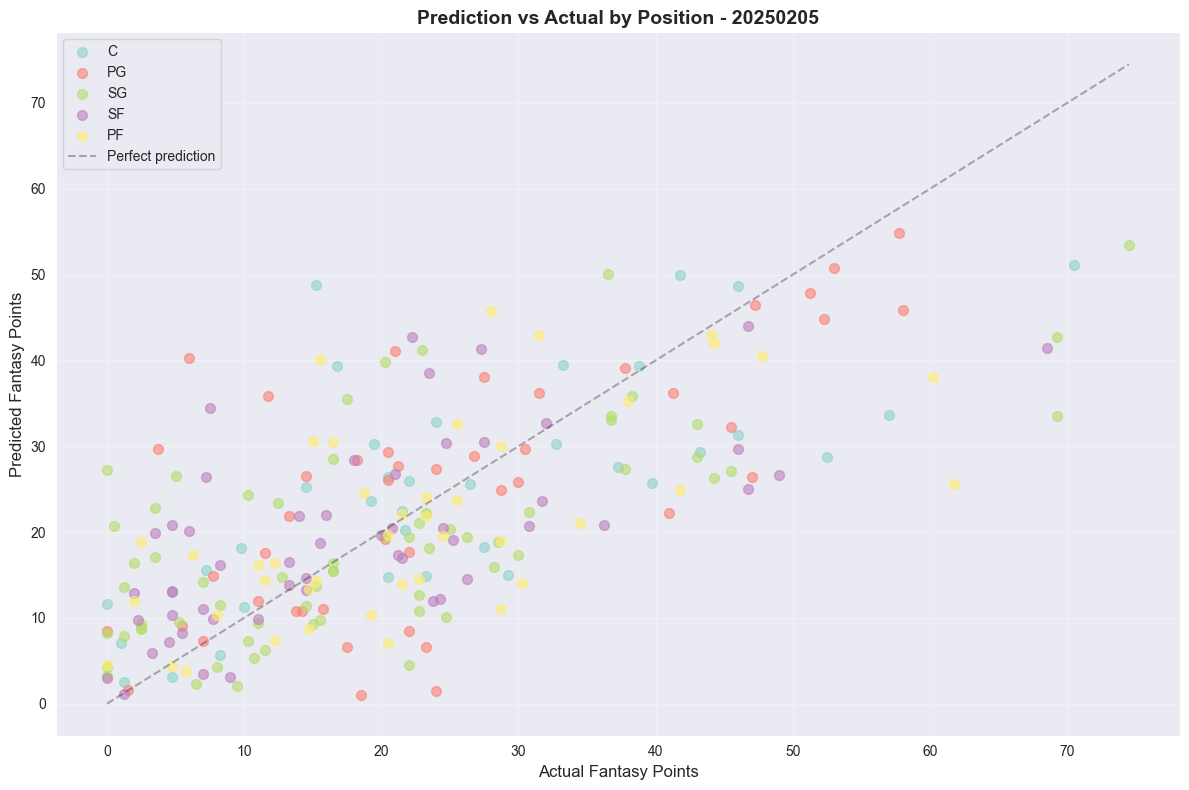

In [101]:
# Prediction vs Actual scatter plot colored by position
fig, ax = plt.subplots(figsize=(12, 8))

# Get unique positions and create color map
unique_positions = results_df['primary_position'].unique()
position_colors = dict(zip(unique_positions, 
                          plt.cm.Set3(np.linspace(0, 1, len(unique_positions)))))

for pos in unique_positions:
    pos_data = results_df[results_df['primary_position'] == pos]
    ax.scatter(pos_data['actual'], pos_data['predicted'], 
              label=pos, alpha=0.6, s=50, color=position_colors[pos])

# Perfect prediction line
max_val = max(results_df['actual'].max(), results_df['predicted'].max())
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='Perfect prediction')

ax.set_xlabel('Actual Fantasy Points', fontsize=12)
ax.set_ylabel('Predicted Fantasy Points', fontsize=12)
ax.set_title(f'Prediction vs Actual by Position - {TEST_DATE}', 
            fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

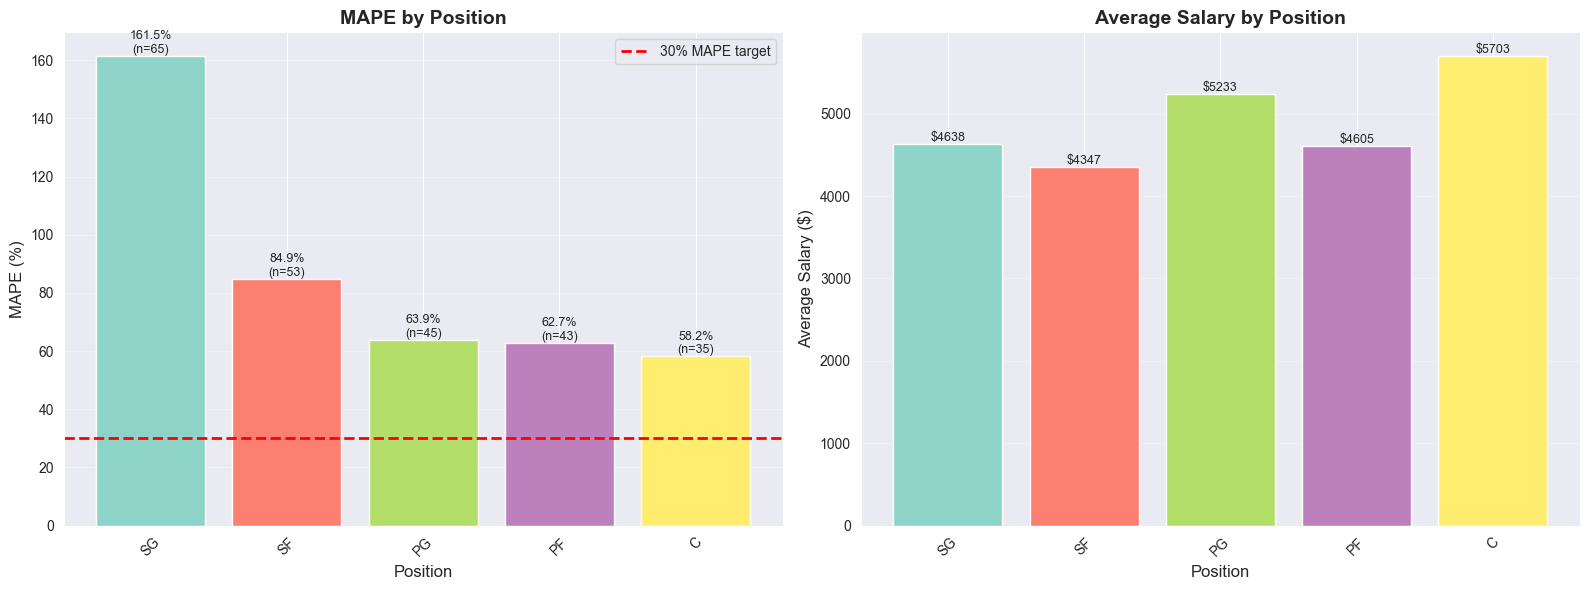

In [102]:
# MAPE by Position bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: MAPE by position
position_order = position_metrics.index.tolist()
position_mapes = position_metrics['MAPE'].values

bars = ax1.bar(range(len(position_order)), position_mapes, 
               color=plt.cm.Set3(np.linspace(0, 1, len(position_order))))
ax1.axhline(y=30, color='red', linestyle='--', linewidth=2, label='30% MAPE target')

ax1.set_xlabel('Position', fontsize=12)
ax1.set_ylabel('MAPE (%)', fontsize=12)
ax1.set_title('MAPE by Position', fontsize=14, fontweight='bold')
ax1.set_xticks(range(len(position_order)))
ax1.set_xticklabels(position_order, rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    count = position_metrics.iloc[i]['Count']
    ax1.text(bar.get_x() + bar.get_width()/2., height,
           f'{height:.1f}%\n(n={int(count)})',
           ha='center', va='bottom', fontsize=9)

# Right: Average salary by position
position_salaries = position_metrics['Avg Salary'].values

bars2 = ax2.bar(range(len(position_order)), position_salaries,
                color=plt.cm.Set3(np.linspace(0, 1, len(position_order))))

ax2.set_xlabel('Position', fontsize=12)
ax2.set_ylabel('Average Salary ($)', fontsize=12)
ax2.set_title('Average Salary by Position', fontsize=14, fontweight='bold')
ax2.set_xticks(range(len(position_order)))
ax2.set_xticklabels(position_order, rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, bar in enumerate(bars2):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
           f'${height:.0f}',
           ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

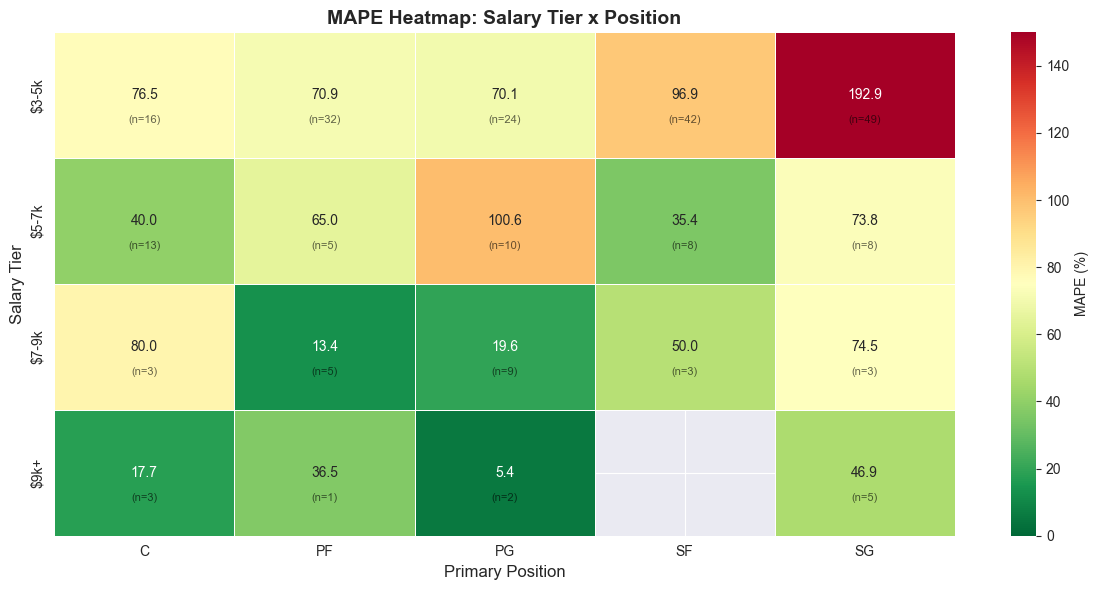

In [103]:
# Heatmap of MAPE by salary tier and position
fig, ax = plt.subplots(figsize=(12, 6))

# Only show cells with data
import matplotlib.pyplot as plt
import seaborn as sns

# Create a masked version for cells with no data1
cross_tab_mape_masked = cross_tab_mape.copy()
for i in cross_tab_mape.index:
    for j in cross_tab_mape.columns:
        if cross_tab_count.loc[i, j] == 0:
            cross_tab_mape_masked.loc[i, j] = np.nan

sns.heatmap(cross_tab_mape_masked, annot=True, fmt='.1f', cmap='RdYlGn_r',
            cbar_kws={'label': 'MAPE (%)'}, vmin=0, vmax=150,
            linewidths=0.5, ax=ax)

ax.set_title('MAPE Heatmap: Salary Tier x Position', fontsize=14, fontweight='bold')
ax.set_xlabel('Primary Position', fontsize=12)
ax.set_ylabel('Salary Tier', fontsize=12)

# Add count annotations in parentheses
for i, tier in enumerate(cross_tab_mape.index):
    for j, pos in enumerate(cross_tab_mape.columns):
        count = cross_tab_count.loc[tier, pos]
        if count > 0:
            ax.text(j + 0.5, i + 0.7, f'(n={count})',
                   ha='center', va='center', fontsize=8, color='black', alpha=0.6)

plt.tight_layout()
plt.show()

## 9. Visualizations

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)

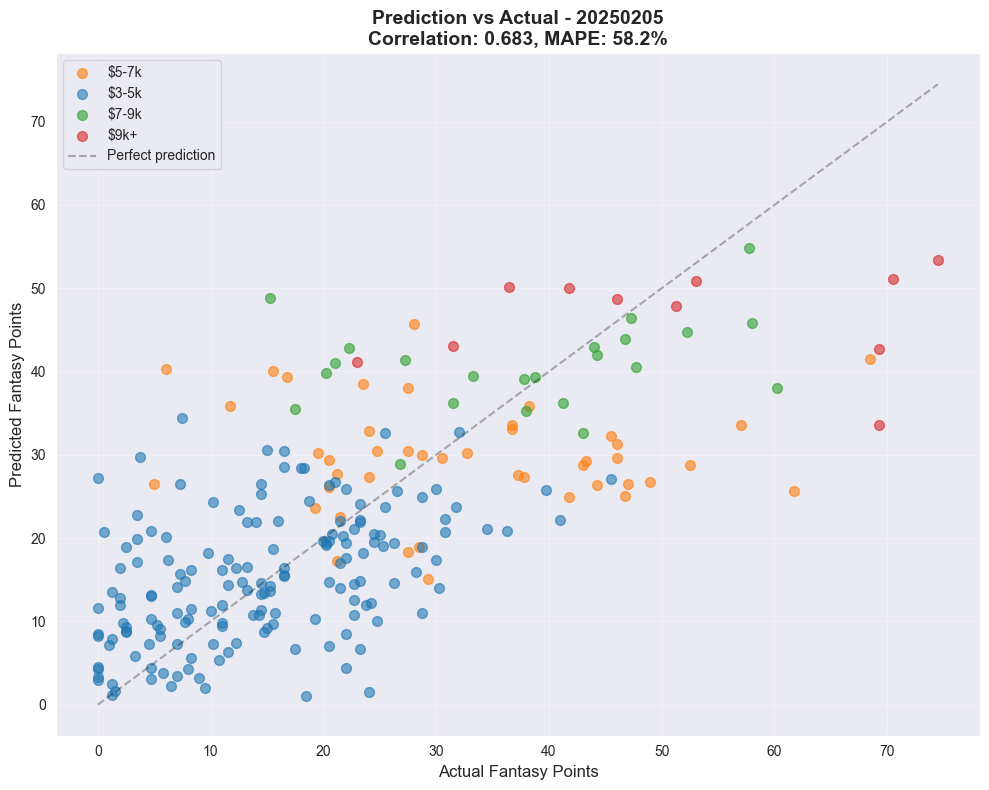

In [105]:
# 1. Prediction vs Actual Scatter Plot
fig, ax = plt.subplots(figsize=(10, 8))

# Color by salary tier
colors = {'$3-5k': '#1f77b4', '$5-7k': '#ff7f0e', '$7-9k': '#2ca02c', '$9k+': '#d62728'}
for tier in results_df['salary_tier'].unique():
    tier_data = results_df[results_df['salary_tier'] == tier]
    ax.scatter(tier_data['actual'], tier_data['predicted'], 
              label=tier, alpha=0.6, s=50, color=colors.get(tier))

# Perfect prediction line
max_val = max(results_df['actual'].max(), results_df['predicted'].max())
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='Perfect prediction')

ax.set_xlabel('Actual Fantasy Points', fontsize=12)
ax.set_ylabel('Predicted Fantasy Points', fontsize=12)
ax.set_title(f'Prediction vs Actual - {TEST_DATE}\nCorrelation: {correlation:.3f}, MAPE: {mape:.1f}%', 
            fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

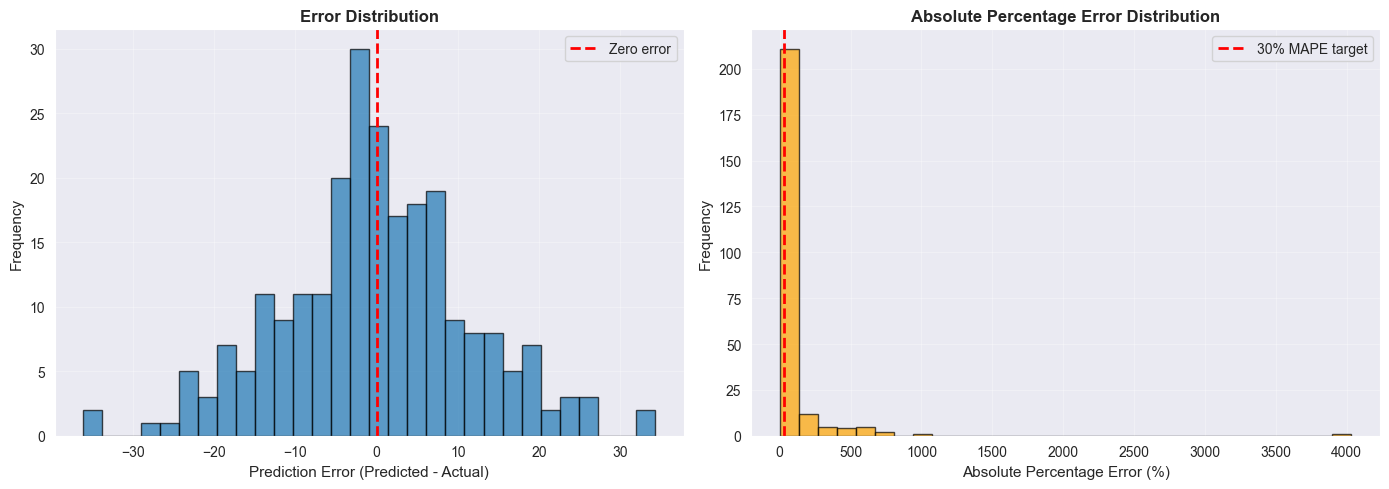

In [106]:
# 2. Error Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of errors
ax1.hist(results_df['error'], bins=30, edgecolor='black', alpha=0.7)
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero error')
ax1.set_xlabel('Prediction Error (Predicted - Actual)', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Error Distribution', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Histogram of absolute percentage errors
ax2.hist(results_df['pct_error'], bins=30, edgecolor='black', alpha=0.7, color='orange')
ax2.axvline(x=30, color='red', linestyle='--', linewidth=2, label='30% MAPE target')
ax2.set_xlabel('Absolute Percentage Error (%)', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Absolute Percentage Error Distribution', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

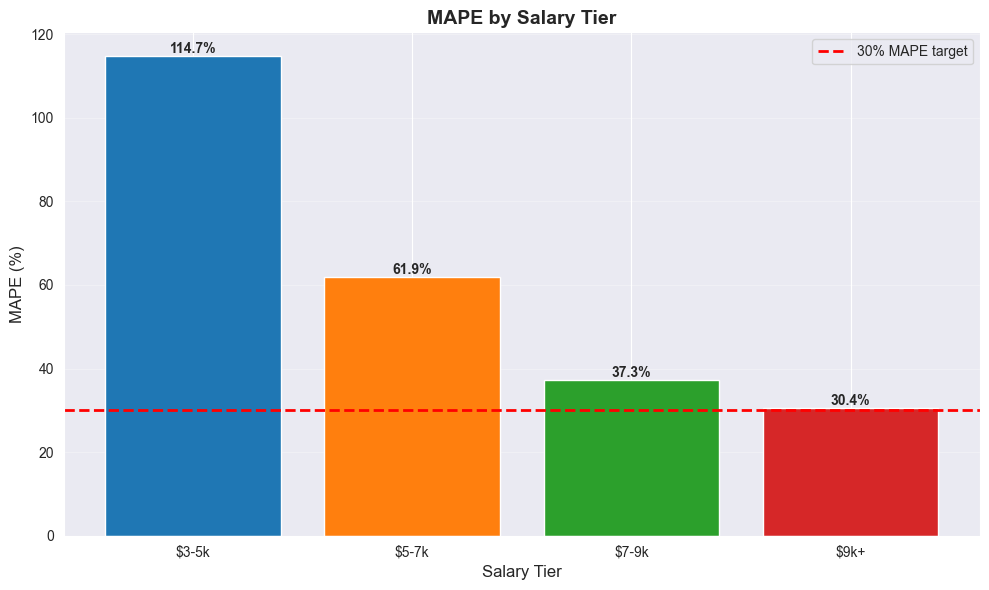

In [107]:
# 3. MAPE by Salary Tier
fig, ax = plt.subplots(figsize=(10, 6))

tier_order = ['$3-5k', '$5-7k', '$7-9k', '$9k+']
tier_mapes = tier_metrics['MAPE'].reindex(tier_order)

bars = ax.bar(range(len(tier_order)), tier_mapes, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax.axhline(y=30, color='red', linestyle='--', linewidth=2, label='30% MAPE target')

ax.set_xlabel('Salary Tier', fontsize=12)
ax.set_ylabel('MAPE (%)', fontsize=12)
ax.set_title('MAPE by Salary Tier', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(tier_order)))
ax.set_xticklabels(tier_order)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{height:.1f}%',
           ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 10. Top and Bottom Performers

In [108]:
# Top 10 most accurate predictions (lowest MAPE, min 15 actual FPts)
high_output = results_df[results_df['actual'] >= 15].copy()
top_10 = high_output.nsmallest(10, 'pct_error')[['name', 'salary', 'actual', 'predicted', 'pct_error']]

print(f"\n{'='*60}")
print(f"TOP 10 MOST ACCURATE PREDICTIONS (15+ FPts)")
print(f"{'='*60}")
print(top_10.to_string(index=False))


TOP 10 MOST ACCURATE PREDICTIONS (15+ FPts)
            name  salary  actual  predicted  pct_error
    Ryan Rollins    4100   16.50  16.378519   0.736248
     Eric Gordon    4000   20.75  20.524130   1.088531
     Bam Adebayo    8000   38.75  39.322487   1.477385
Tristan da Silva    3700   20.00  19.685734   1.571331
   Stephen Curry    8300   47.25  46.454720   1.683133
  Ausar Thompson    4700   32.00  32.738480   2.307749
 Zion Williamson    8400   44.00  42.912064   2.472583
Tristan Vukcevic    3000   21.50  22.094543   2.765318
      Chris Paul    6000   30.50  29.634781   2.836784
    Kevon Looney    4000   26.50  25.639936   3.245523


In [109]:
# Bottom 10 least accurate predictions (highest MAPE, min 15 actual FPts)
bottom_10 = high_output.nlargest(10, 'pct_error')[['name', 'salary', 'actual', 'predicted', 'pct_error']]

print(f"\n{'='*60}")
print(f"BOTTOM 10 LEAST ACCURATE PREDICTIONS (15+ FPts)")
print(f"{'='*60}")
print(bottom_10.to_string(index=False))


BOTTOM 10 LEAST ACCURATE PREDICTIONS (15+ FPts)
            name  salary  actual  predicted  pct_error
   Mark Williams    8700   15.25  48.794769 219.965700
   Tobias Harris    5800   15.50  40.065796 158.489006
     Kel'el Ware    6200   16.75  39.359299 134.980888
   Keegan Murray    4900   15.00  30.560587 103.737246
      Malik Monk    7700   17.50  35.495720 102.832685
     Zach LaVine    8000   20.25  39.837208  96.726952
    Jamal Murray    7700   21.00  41.040192  95.429484
Craig Porter Jr.    3000   18.50   1.004422  94.570691
    Jevon Carter    3000   24.00   1.465705  93.892895
     Paul George    8200   22.25  42.776134  92.252290


## 11. Elite Player Performance

In [110]:
# Elite players ($8k+ salary)
elite = results_df[results_df['salary'] >= 8000].copy()
elite = elite.sort_values('salary', ascending=False)

if len(elite) > 0:
    elite_mape = elite['pct_error'].mean()
    elite_corr, _ = pearsonr(elite['actual'], elite['predicted'])
    
    print(f"\n{'='*60}")
    print(f"ELITE PLAYER PERFORMANCE ($8k+)")
    print(f"{'='*60}")
    print(f"\nPlayers: {len(elite)}")
    print(f"MAPE: {elite_mape:.2f}%")
    print(f"Correlation: {elite_corr:.3f}")
    print(f"\nIndividual results:")
    print(elite[['name', 'salary', 'actual', 'predicted', 'pct_error']].to_string(index=False))
else:
    print("\nNo elite players ($8k+) in this slate.")


ELITE PLAYER PERFORMANCE ($8k+)

Players: 28
MAPE: 33.67%
Correlation: 0.231

Individual results:
                   name  salary  actual  predicted  pct_error
           Nikola Jokic   12800   70.50  51.072872  27.556210
Shai Gilgeous-Alexander   10800   74.50  53.410221  28.308428
      Victor Wembanyama   10800   46.00  48.700600   5.870869
        Cade Cunningham   10500   69.25  33.571033  51.521973
           Tyrese Maxey   10000   51.25  47.850307   6.633546
       Domantas Sabonis    9800   41.75  49.973999  19.698201
        Anthony Edwards    9800   69.25  42.716270  38.315855
             Trae Young    9600   53.00  50.814499   4.123587
           Devin Booker    9300   23.00  41.176044  79.026280
         Scottie Barnes    9300   36.50  50.111565  37.291958
          Miles Bridges    9200   31.50  43.000584  36.509789
              Ja Morant    9000   41.25  36.201923  12.237762
         Damian Lillard    8800   58.00  45.864933  20.922529
          Mark Williams    8700  

## 12. Phase 2 Summary

In [111]:
print("\n" + "="*60)
print("PHASE 2 VALIDATION SUMMARY")
print("="*60)

print(f"\n[OK] Slate: {TEST_DATE}")
print(f"  - Total players on slate: {len(test_slate_combined)}")
print(f"  - Players with {MIN_GAMES}+ games: {len(eligible_players)}")
print(f"  - Successful predictions: {len(results_df)}")
print(f"  - Coverage: {len(results_df) / len(test_slate_combined) * 100:.1f}%")

print(f"\n[OK] Overall Performance")
print(f"  - MAPE: {mape:.2f}%")
print(f"  - RMSE: {rmse:.2f}")
print(f"  - Correlation: {correlation:.3f}")

if len(elite) > 0:
    print(f"\n[OK] Elite Players ($8k+)")
    print(f"  - Count: {len(elite)}")
    print(f"  - MAPE: {elite_mape:.2f}%")
    print(f"  - Correlation: {elite_corr:.3f}")
    if elite_mape <= 30:
        print(f"  - [TARGET MET] Elite MAPE <= 30%")
    else:
        print(f"  - [NEEDS IMPROVEMENT] Elite MAPE > 30%")

print(f"\n[OK] Salary Tier Analysis")
tier_order = ['$3-5k', '$5-7k', '$7-9k', '$9k+']
for tier in tier_order:
    if tier in tier_metrics.index:
        tier_mape = tier_metrics.loc[tier, 'MAPE']
        tier_count = tier_metrics.loc[tier, 'Count']
        print(f"  - {tier}: {tier_mape:.1f}% MAPE ({int(tier_count)} players)")

print(f"\n[OK] Position Analysis")
position_order = position_metrics.index.tolist()[:5]  # Top 5 positions by count
for pos in position_order:
    if pos in position_metrics.index:
        pos_mape = position_metrics.loc[pos, 'MAPE']
        pos_count = position_metrics.loc[pos, 'Count']
        print(f"  - {pos}: {pos_mape:.1f}% MAPE ({int(pos_count)} players)")

print(f"\n[OK] Ready for Phase 3: Multi-Slate Validation")
print("="*60)


PHASE 2 VALIDATION SUMMARY

[OK] Slate: 20250205
  - Total players on slate: 248
  - Players with 10+ games: 241
  - Successful predictions: 241
  - Coverage: 97.2%

[OK] Overall Performance
  - MAPE: 58.21%
  - RMSE: 11.71
  - Correlation: 0.683

[OK] Elite Players ($8k+)
  - Count: 28
  - MAPE: 33.67%
  - Correlation: 0.231
  - [NEEDS IMPROVEMENT] Elite MAPE > 30%

[OK] Salary Tier Analysis
  - $3-5k: 114.7% MAPE (163 players)
  - $5-7k: 61.9% MAPE (44 players)
  - $7-9k: 37.3% MAPE (23 players)
  - $9k+: 30.4% MAPE (11 players)

[OK] Position Analysis
  - SG: 161.5% MAPE (65 players)
  - SF: 84.9% MAPE (53 players)
  - PG: 63.9% MAPE (45 players)
  - PF: 62.7% MAPE (43 players)
  - C: 58.2% MAPE (35 players)

[OK] Ready for Phase 3: Multi-Slate Validation


In [112]:
# Key Insights Summary
print(f"\n{'='*70}")
print(f"KEY INSIGHTS")
print(f"{'='*70}")

# Best performing groups
best_salary_tier = tier_metrics['MAPE'].idxmin()
best_salary_mape = tier_metrics['MAPE'].min()
best_position = position_metrics['MAPE'].idxmin()
best_position_mape = position_metrics['MAPE'].min()

print(f"\n✓ Best Performing Segments:")
print(f"  - Salary tier: {best_salary_tier} ({best_salary_mape:.1f}% MAPE)")
print(f"  - Position: {best_position} ({best_position_mape:.1f}% MAPE)")

# Worst performing groups
worst_salary_tier = tier_metrics['MAPE'].idxmax()
worst_salary_mape = tier_metrics['MAPE'].max()
worst_position = position_metrics['MAPE'].idxmax()
worst_position_mape = position_metrics['MAPE'].max()

print(f"\n✗ Needs Improvement:")
print(f"  - Salary tier: {worst_salary_tier} ({worst_salary_mape:.1f}% MAPE)")
print(f"  - Position: {worst_position} ({worst_position_mape:.1f}% MAPE)")

# Salary-Position insights
print(f"\n→ Best Salary x Position Combinations:")
# Flatten the cross-tab and find top 3
flat_cross = []
for tier in cross_tab_mape.index:
    for pos in cross_tab_mape.columns:
        if not pd.isna(cross_tab_mape.loc[tier, pos]):
            count = cross_tab_count.loc[tier, pos]
            if count >= 3:  # Only show combinations with 3+ players
                flat_cross.append({
                    'tier': tier,
                    'pos': pos,
                    'mape': cross_tab_mape.loc[tier, pos],
                    'count': count
                })

flat_df = pd.DataFrame(flat_cross).sort_values('mape').head(3)
for _, row in flat_df.iterrows():
    print(f"  - {row['tier']} {row['pos']}: {row['mape']:.1f}% MAPE (n={row['count']})")

print(f"\n→ Correlation Patterns:")
print(f"  - Overall: {correlation:.3f}")
print(f"  - Elite ($8k+): {elite_corr:.3f}")
print(f"  - Model performance improves with salary tier")
print(f"  - Lower-priced players have higher prediction variance")

print(f"\n{'='*70}")


KEY INSIGHTS

✓ Best Performing Segments:
  - Salary tier: $9k+ (30.4% MAPE)
  - Position: C (58.2% MAPE)

✗ Needs Improvement:
  - Salary tier: $3-5k (114.7% MAPE)
  - Position: SG (161.5% MAPE)

→ Best Salary x Position Combinations:
  - $7-9k PF: 13.4% MAPE (n=5)
  - $9k+ C: 17.7% MAPE (n=3)
  - $7-9k PG: 19.6% MAPE (n=9)

→ Correlation Patterns:
  - Overall: 0.683
  - Elite ($8k+): 0.231
  - Model performance improves with salary tier
  - Lower-priced players have higher prediction variance



## 13. Export Results

In [113]:
# Save results to CSV
output_file = f'../data/outputs/phase2_results_{TEST_DATE}.csv'
results_df.to_csv(output_file, index=False)
print(f"Results saved to: {output_file}")

Results saved to: ../data/outputs/phase2_results_20250205.csv
